In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import numpy as np

In [11]:
# Read all CSV files from the different_errors directory
def load_experimental_data(directory):
    all_data = []
    
    # Create a Path object for the directory
    dir_path = Path(directory)
    
    # Iterate through all CSV files in the directory
    for file_path in dir_path.glob('*.csv'):
        df = pd.read_csv(file_path)
        df['run'] = int(file_path.stem.split('_')[-1].replace('run', ''))
        all_data.append(df)
    
    # Combine all dataframes
    return pd.concat(all_data, ignore_index=True)

In [13]:
# Load the data
directory='different_errors'
df = load_experimental_data(directory)

In [16]:
# Function to plot the aggregated results
def plot_aggregated_error_per_column(directory, y_col, include_initialization=False):
    # Load the data
    df = load_experimental_data(directory)

    # Group by errorBound and query number, then calculate mean and std
    agg_df = df.groupby(['errorBound', 'i']).agg(
        mean_time=(y_col, 'mean'),
        std_time=(y_col, 'std')
    ).reset_index()

    # Optionally exclude the first point (initialization time)
    if not include_initialization:
        agg_df = agg_df[agg_df['i'] != 0]

    # Define the custom color palette
    colors = ['black', 'red', 'green']
    color_palette = {error_bound: colors[i % len(colors)] for i, error_bound in enumerate(agg_df['errorBound'].unique())}

    # Create query index for x-axis (assuming 'i' column represents query sequence)
    plt.figure(figsize=(12, 5))
    fontsize=14
    # Plot a line for each error bound without markers
    for error_bound in agg_df['errorBound'].unique():
        data = agg_df[agg_df['errorBound'] == error_bound]
        label = 'Exact' if error_bound == 0 else f'{error_bound * 100:.0f}%'
        plotted_data = data if include_initialization else data[1:]
        plt.plot(plotted_data['i'], plotted_data['mean_time'], 
                 label=label, 
                 linewidth=2,
                 color=color_palette[error_bound])

    plt.xlabel('Query Sequence', fontsize=fontsize, fontweight='bold')
    plt.ylabel(y_col, fontsize=fontsize, fontweight='bold')
    plt.legend(fontsize = fontsize, frameon=False)  # Remove the box around the legend
    
    # Remove the grid lines behind the plot
    plt.grid(False)

    # Rotate x-axis labels if there are many queries
    plt.xticks(fontsize = fontsize, rotation=0)
    plt.yticks(fontsize = fontsize)
    plt.tight_layout()
    plt.show()


# Read all CSV files from the different_errors directory
def load_experimental_data(directory):
    all_data = []
    
    # Create a Path object for the directory
    dir_path = Path(directory)
    
    # Iterate through all CSV files in the directory
    for file_path in dir_path.glob('*.csv'):
        df = pd.read_csv(file_path)
        df['run'] = int(file_path.stem.split('_')[-1].replace('run', ''))
        df['errorBound'] = float(file_path.stem.split('_')[1])
        all_data.append(df)
    
    # Combine all dataframes
    return pd.concat(all_data, ignore_index=True)

# Function to plot the aggregated results
def plot_aggregated_error_per_column(directory, y_col, include_initialization=False):
    # Load the data
    df = load_experimental_data(directory)

    # Group by errorBound and query number, then calculate mean and std
    agg_df = df.groupby(['errorBound', 'i']).agg(
        mean_time=(y_col, 'mean'),
        std_time=(y_col, 'std')
    ).reset_index()

    # Optionally exclude the first point (initialization time)
    if not include_initialization:
        agg_df = agg_df[agg_df['i'] != 0]

    # Define the custom color palette
    colors = ['black', 'red', 'green']
    color_palette = {error_bound: colors[i % len(colors)] for i, error_bound in enumerate(agg_df['errorBound'].unique())}

    # Create query index for x-axis (assuming 'i' column represents query sequence)
    plt.figure(figsize=(12, 5))
    fontsize=14
    # Plot a line for each error bound without markers
    for error_bound in agg_df['errorBound'].unique():
        data = agg_df[agg_df['errorBound'] == error_bound]
        label = 'Exact' if error_bound == 0 else f'{error_bound * 100:.0f}%'
        plt.plot(data['i'], data['mean_time'], 
                 label=label, 
                 linewidth=2,
                 color=color_palette[error_bound])

    plt.xlabel('Query Sequence', fontsize=fontsize, fontweight='bold')
    plt.ylabel(y_col, fontsize=fontsize, fontweight='bold')
    plt.legend(fontsize = fontsize, frameon=False)  # Remove the box around the legend
    
    # Remove the grid lines behind the plot
    plt.grid(False)

    # Rotate x-axis labels if there are many queries
    plt.xticks(fontsize = fontsize, rotation=0)
    plt.yticks(fontsize = fontsize)

    # Adjust x-axis to start from 1 if initialization is excluded
    if not include_initialization:
        plt.xlim(left=1)

    plt.tight_layout()
    plt.show()
    
# Function to plot the line chart along with a bar chart showing the summation of time compared to all errors
def plot_aggregated_error_per_column_with_bars(directory, y_col, include_initialization=False):
    # Load the data
    df = load_experimental_data(directory)

    # Group by errorBound and query number, then calculate mean and std
    agg_df = df.groupby(['errorBound', 'i']).agg(
        mean_time=(y_col, 'mean'),
        std_time=(y_col, 'std')
    ).reset_index()

    # Optionally exclude the first point (initialization time)
    if not include_initialization:
        agg_df = agg_df[agg_df['i'] != 0]

    # Define the custom color palette
    colors = ['black', 'red', 'green']
    color_palette = {error_bound: colors[i % len(colors)] for i, error_bound in enumerate(agg_df['errorBound'].unique())}

    # Create a figure with two subplots side by side with different sizes
    fig = plt.figure(figsize=(15, 5))
    gs = fig.add_gridspec(1, 2, width_ratios=[3, 1])
    ax1 = fig.add_subplot(gs[0])
    ax2 = fig.add_subplot(gs[1])
    fontsize=14

    # Plot a line for each error bound without markers on the first subplot
    for error_bound in agg_df['errorBound'].unique():
        data = agg_df[agg_df['errorBound'] == error_bound]
        label = 'Exact' if error_bound == 0 else f'{error_bound * 100:.0f}%'
        ax1.plot(data['i'], data['mean_time'], 
                 label=label, 
                 linewidth=2,
                 color=color_palette[error_bound])

    ax1.set_xlabel('Query Sequence', fontsize=fontsize, fontweight='bold')
    ax1.set_ylabel(y_col, fontsize=fontsize, fontweight='bold')
    ax1.legend(fontsize = fontsize, frameon=False)  # Remove the box around the legend
    
    # Remove the grid lines behind the plot
    ax1.grid(False)

    # Rotate x-axis labels if there are many queries
    ax1.tick_params(axis='x', labelsize=fontsize, rotation=0)
    ax1.tick_params(axis='y', labelsize=fontsize)

    # Adjust x-axis to start from 1 if initialization is excluded
    if not include_initialization:
        ax1.set_xlim(left=1)

    # Create the bar chart on the second subplot
    total_times = agg_df.groupby('errorBound')['mean_time'].sum().reset_index()
    total_times['label'] = total_times['errorBound'].apply(lambda x: 'Exact' if x == 0 else f'{x * 100:.0f}%')
    bars = ax2.bar(total_times['label'], total_times['mean_time'], alpha=0.7)

    # Set the colors of the bars to match the line colors
    for bar, error_bound in zip(bars, total_times['errorBound']):
        bar.set_color(color_palette[error_bound])

    ax2.set_xlabel('Error Bound', fontsize=fontsize, fontweight='bold')
    ax2.set_ylabel(f'Total {y_col}', fontsize=fontsize, fontweight='bold')
    ax2.tick_params(axis='x', labelsize=fontsize, rotation=0)
    ax2.tick_params(axis='y', labelsize=fontsize)

    plt.tight_layout()
    plt.show()

# Function to plot only the bar chart showing the summation of time compared to all errors
def plot_aggregated_error_per_column_bars_only(directory, y_col, include_initialization=False):
    # Load the data
    df = load_experimental_data(directory)

    # Group by errorBound and query number, then calculate mean and std
    agg_df = df.groupby(['errorBound', 'i']).agg(
        mean_time=(y_col, 'mean'),
        std_time=(y_col, 'std')
    ).reset_index()

    # Optionally exclude the first point (initialization time)
    if not include_initialization:
        agg_df = agg_df[agg_df['i'] != 0]

    # Define the custom color palette
    colors = ['black', 'red', 'green']
    color_palette = {error_bound: colors[i % len(colors)] for i, error_bound in enumerate(agg_df['errorBound'].unique())}

    # Create query index for x-axis (assuming 'i' column represents query sequence)
    plt.figure(figsize=(12, 5))
    fontsize=14

    # Create the bar chart
    total_times = agg_df.groupby('errorBound')['mean_time'].sum().reset_index()
    total_times['label'] = total_times['errorBound'].apply(lambda x: 'Exact' if x == 0 else f'{x * 100:.0f}%')
    bars = plt.bar(total_times['label'], total_times['mean_time'], alpha=0.7)

    # Set the colors of the bars to match the line colors
    for bar, error_bound in zip(bars, total_times['errorBound']):
        bar.set_color(color_palette[error_bound])

    plt.xlabel('Error Bound', fontsize=fontsize, fontweight='bold')
    plt.ylabel(f'Total {y_col}', fontsize=fontsize, fontweight='bold')
    
    # Rotate x-axis labels if there are many queries
    plt.xticks(fontsize = fontsize, rotation=0)
    plt.yticks(fontsize = fontsize)

    plt.tight_layout()
    plt.show()



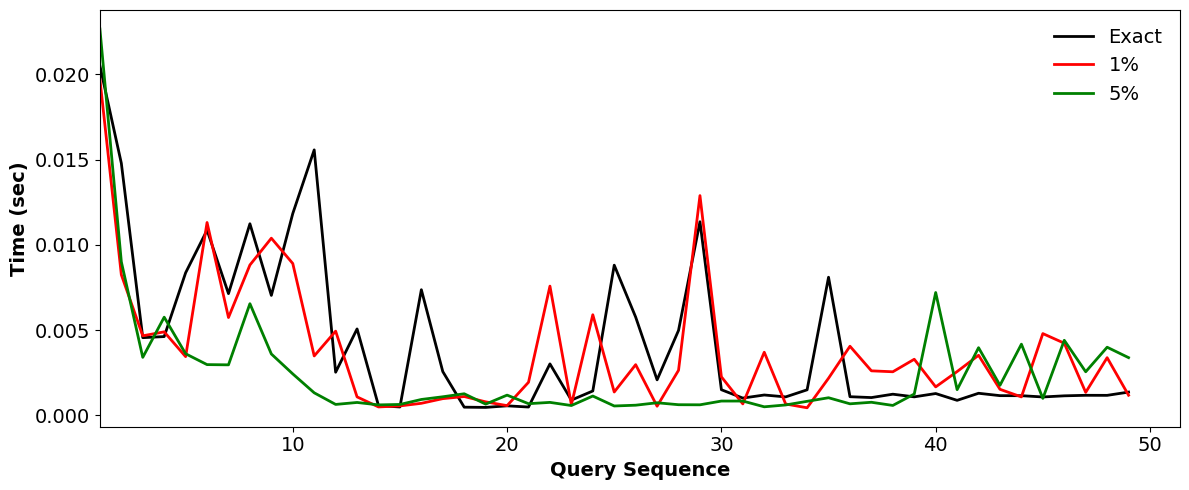

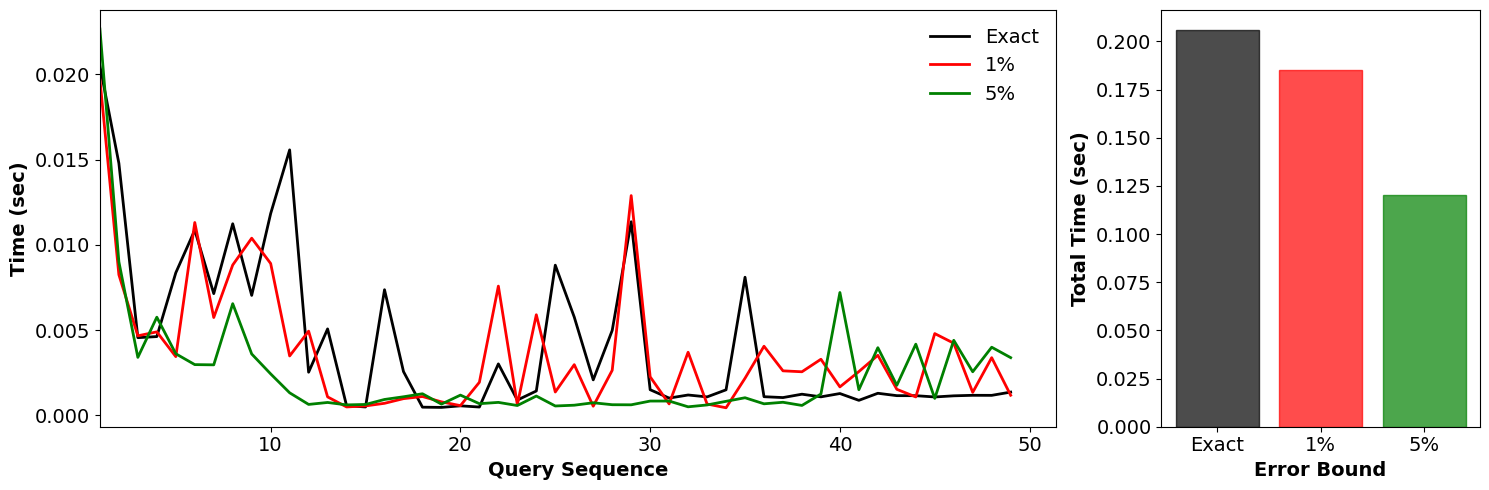

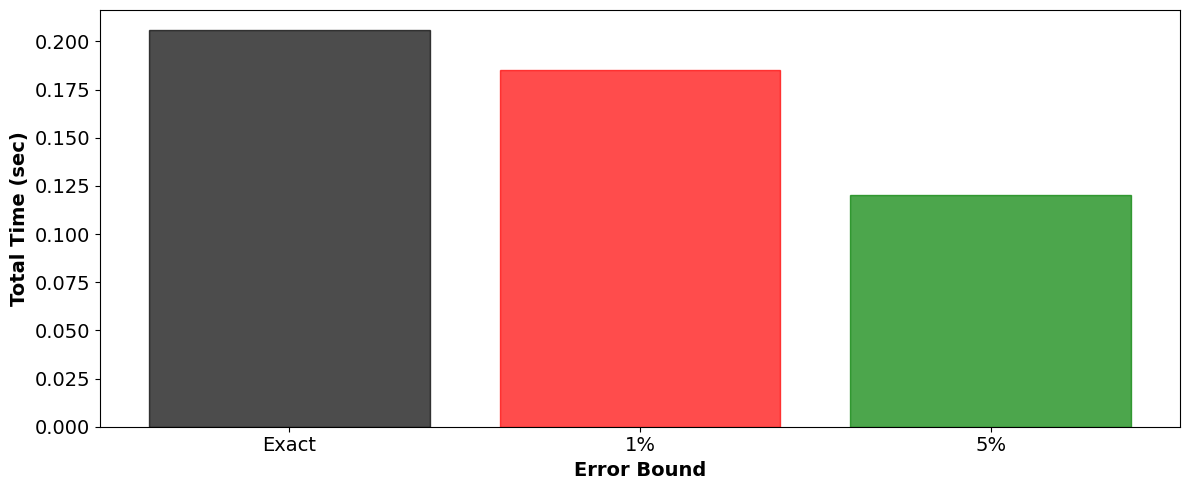

In [17]:
plot_aggregated_error_per_column(directory, 'Time (sec)')
plot_aggregated_error_per_column_with_bars(directory, 'Time (sec)', include_initialization=False)
plot_aggregated_error_per_column_bars_only(directory, 'Time (sec)', include_initialization=False)

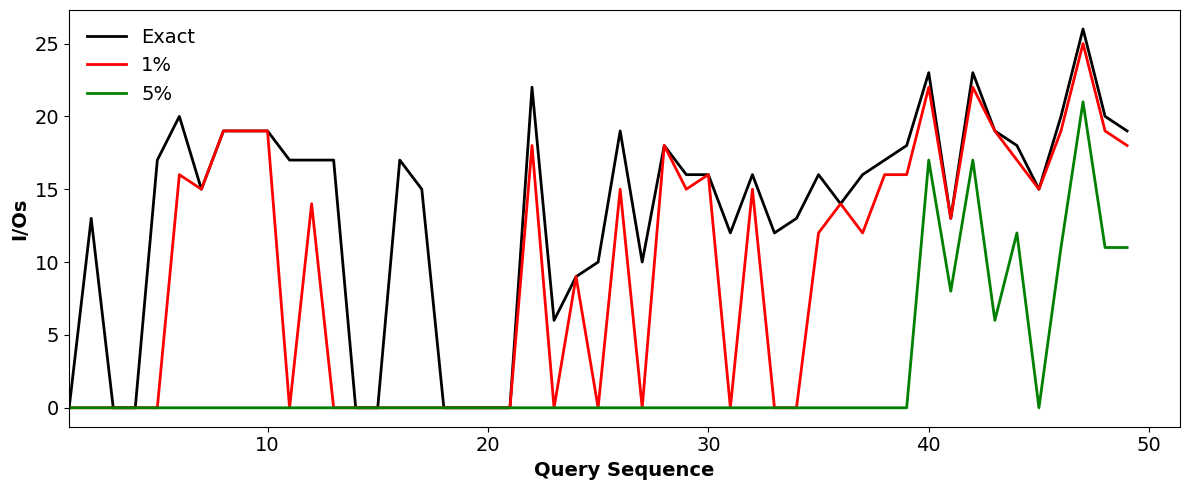

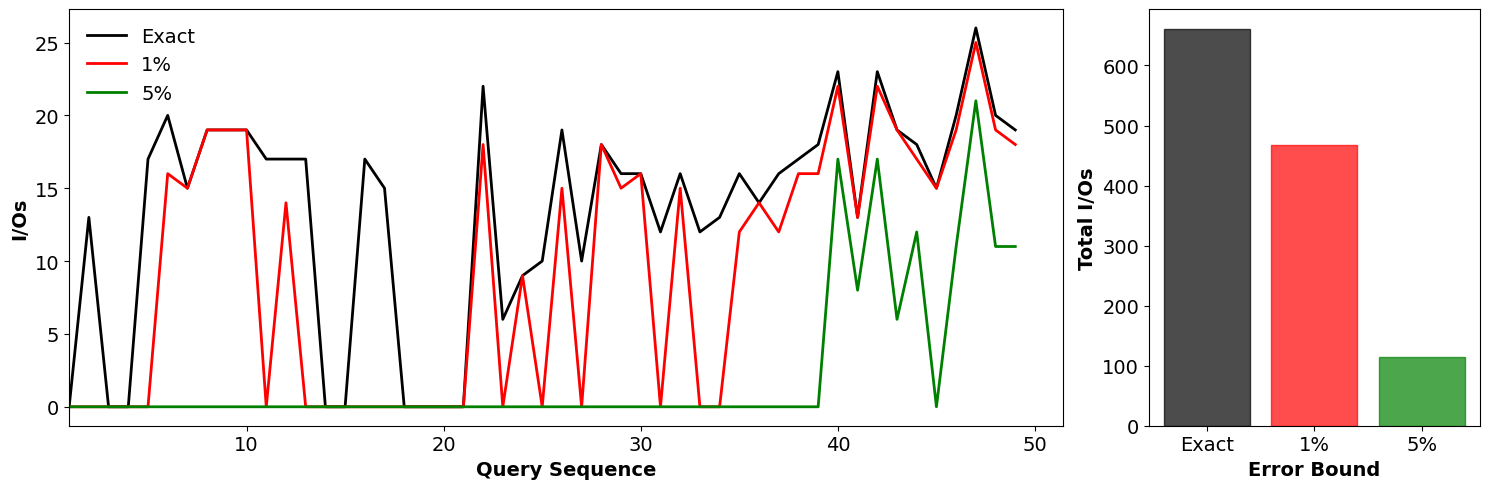

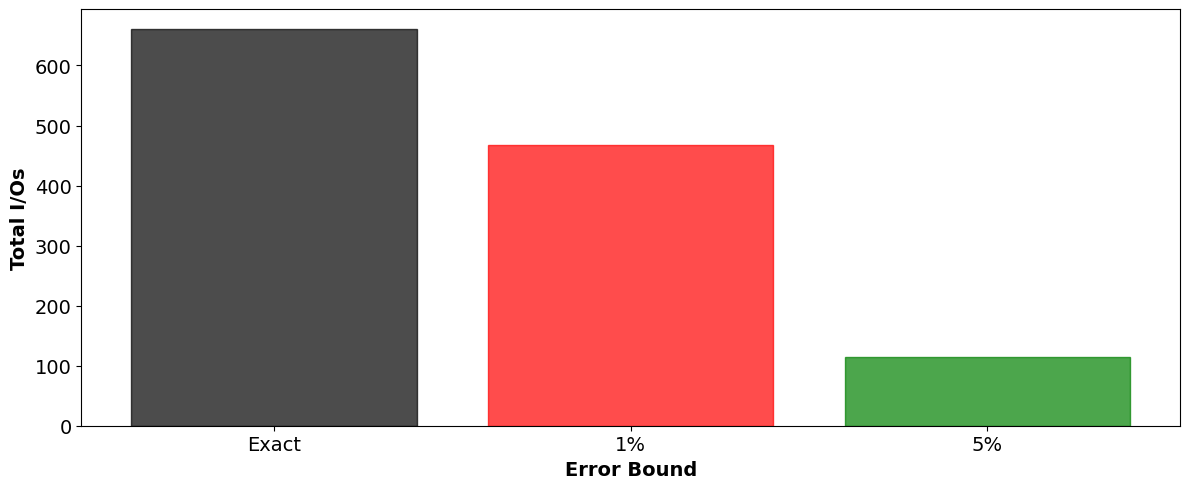

In [19]:
plot_aggregated_error_per_column(directory, 'I/Os')
plot_aggregated_error_per_column_with_bars(directory, 'I/Os', include_initialization=False)
plot_aggregated_error_per_column_bars_only(directory, 'I/Os', include_initialization=False)